# 1. Model Optimization Overview

**Project:** Predicting Rural Water Point Functionality Using Data Mining

**Task:** Multiclass classification of `functional3`: Functional, Partially functional, or Abandoned or not functional.

This notebook implements **Stage 7 — Model Optimization and Final Model Selection**. Notebook 04 completed the baseline comparison. Its saved training-CV evidence is imported below to verify the Random Forest and Decision Tree shortlist and the minority-class concern.

We first investigate class weighting, then perform bounded hyperparameter searches. Macro-F1 remains the primary comparison metric. We select and lock the final configuration using training cross-validation, fit it on all training rows, and perform **one final holdout evaluation**.

**No hyperparameter or model-selection decision will use `y_test`.** Existing preprocessing decisions, notebooks, raw data and saved artifacts are preserved. No backend, frontend or deployment artifact is produced.

# 2. Load Libraries and Configuration

Seed 42 preserves the existing split and shuffled folds. Project paths are detected from the repository root or `notebooks/`; no attachment fallback or machine-specific source path is used. We print the environment because serialized scikit-learn objects can depend on the version used to create them.

In [31]:
from pathlib import Path
import hashlib
import json
import re
import platform
import warnings
from sklearn.exceptions import InconsistentVersionWarning
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import joblib
from IPython.display import display, Markdown
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, make_scorer, precision_score, recall_score, f1_score, accuracy_score

RANDOM_STATE = 42
TEST_SIZE = 0.20
TARGET = "functional3"
CLASS_ORDER = ["Functional", "Partially functional", "Abandoned or not functional"]
# Find the project root from the kernel working directory. This supports
# launching from the project root, notebooks/, or another project subfolder.
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    (candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents)
     if (candidate / "data/raw/water_pump_functionality.xlsx").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Project root could not be found. Start the kernel inside the project "
        "containing data/raw/water_pump_functionality.xlsx. "
        f"Current working directory: {CURRENT_DIR}"
    )
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
print("Project root:", PROJECT_ROOT)
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)
print("Python:", platform.python_version(), "| sklearn:", sklearn.__version__, "| pandas:", pd.__version__)

from html.parser import HTMLParser
from time import perf_counter
import ast

holdout_evaluation_count = 0


Project root: E:\SLIIT\SLIIT Y3S2\FDM\fdm-water-point-functionality
Python: 3.11.9 | sklearn: 1.8.0 | pandas: 2.2.3


# 3. Load and Verify Project Data

The runtime audit checks actual files under `data/processed/`, `models/` and `reports/`, plus `requirements.txt`. Optional artifacts provide verification evidence only; they are not required inputs to optimization. A saved pipeline with a version mismatch is never used for CV.

Notebook 03 is the preprocessing authority, while notebook 04 is the baseline-results authority. The older viva document disagrees with the implemented leakage removal and encoding; this notebook follows the implemented notebooks. Class distributions are displayed for split verification only.

In [32]:
raw_path = DATA_RAW / "water_pump_functionality.xlsx"
source03_path = PROJECT_ROOT / "notebooks" / "03_preprocessing.ipynb"
for path in [raw_path, source03_path]:
    assert path.is_file(), f"Required project source missing: {path}"
artifact_paths = {name: DATA_PROCESSED / name for name in [
    "X_train_processed.csv", "X_test_processed.csv", "y_train.csv", "y_test.csv", "feature_names.csv"
]}
artifact_paths["preprocessing_pipeline.joblib"] = MODELS_DIR / "preprocessing_pipeline.joblib"
artifact_paths["preprocessing_decisions.md"] = REPORTS_DIR / "preprocessing_decisions.md"
purposes = {
    "X_train_processed.csv": "Compare reconstructed training values and schema",
    "X_test_processed.csv": "Verify holdout shape/schema only; no model evaluation",
    "y_train.csv": "Verify original training label order",
    "y_test.csv": "Verify reserved holdout split; no model evaluation",
    "feature_names.csv": "Compare reconstructed feature names",
    "preprocessing_pipeline.joblib": "Optional train-only parity check if version-compatible",
    "preprocessing_decisions.md": "Read the existing decision record; preserve notebook 03 logic",
}
artifact_audit = pd.DataFrame([
    {"Artifact": name, "Path": path.relative_to(PROJECT_ROOT).as_posix(),
     "Exists": path.exists(), "Purpose": purposes[name]}
    for name, path in artifact_paths.items()
])
display(artifact_audit)
existing_artifacts = artifact_audit.loc[artifact_audit["Exists"], "Artifact"].tolist()
missing_artifacts = artifact_audit.loc[~artifact_audit["Exists"], "Artifact"].tolist()
display(Markdown("**Observation:** "
    + ("Present: " + ", ".join(existing_artifacts) + ". " if existing_artifacts else "None of the optional audit files is present. ")
    + ("Missing: " + ", ".join(missing_artifacts) + ". Saved contents of these files cannot be verified." if missing_artifacts else
       "All listed optional audit files are present; the following checks assess their contents.")))

# Inventory real contents, including unexpected files, without writing anything.
for folder in [DATA_PROCESSED, MODELS_DIR, REPORTS_DIR]:
    contents = sorted(path.relative_to(PROJECT_ROOT).as_posix()
                      for path in folder.rglob("*") if path.is_file()) if folder.is_dir() else []
    print(folder.relative_to(PROJECT_ROOT).as_posix() + ":", contents or "No files present")

requirements_path = PROJECT_ROOT / "requirements.txt"
requirements_text = requirements_path.read_text() if requirements_path.is_file() else None
if requirements_text is None:
    print("requirements.txt is absent; no project dependency constraint can be verified.")
else:
    sklearn_requirements = [line.strip() for line in requirements_text.splitlines()
                            if re.match(r"\s*scikit[-_]learn\b", line, flags=re.I)]
    print("requirements.txt scikit-learn declarations:", sklearn_requirements or "No direct constraint found")
print("Runtime scikit-learn version:", sklearn.__version__)
if artifact_paths["preprocessing_decisions.md"].is_file():
    preprocessing_decisions = artifact_paths["preprocessing_decisions.md"].read_text()
    print("Existing decision report read for context. Notebook 03 remains the implementation authority.")

# Hash every existing file under these folders, not only the expected artifacts.
protected_paths = set()
for folder in [DATA_RAW, DATA_PROCESSED, MODELS_DIR, REPORTS_DIR]:
    if folder.is_dir():
        protected_paths.update(path for path in folder.rglob("*") if path.is_file())
protected_paths.update(PROJECT_ROOT.joinpath("notebooks").glob("0[1234]*.ipynb"))
if requirements_path.is_file():
    protected_paths.add(requirements_path)
def file_hash(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()
protected_hashes = {path: file_hash(path) for path in protected_paths}
df = pd.read_excel(raw_path)
source03 = json.loads(source03_path.read_text(encoding="utf-8"))
assert TARGET in df.columns and not df[TARGET].isna().any()
assert set(df[TARGET]) == set(CLASS_ORDER)
assert df["id"].is_unique, "Unique source IDs are needed for the overlap audit."
print("Raw dataset shape:", df.shape)

source04_path = PROJECT_ROOT / "notebooks/04_model_development.ipynb"
assert source04_path.is_file(), "Notebook 04 is required as baseline evidence."
source04 = json.loads(source04_path.read_text())


,Artifact,Path,Exists,Purpose
0,X_train_processed.csv,data/processed/X_train_processed.csv,True,Compare reconstructed training values and schema
1,X_test_processed.csv,data/processed/X_test_processed.csv,True,Verify holdout shape/schema only; no model evaluation
2,y_train.csv,data/processed/y_train.csv,True,Verify original training label order
3,y_test.csv,data/processed/y_test.csv,True,Verify reserved holdout split; no model evaluation
4,feature_names.csv,data/processed/feature_names.csv,True,Compare reconstructed feature names
5,preprocessing_pipeline.joblib,models/preprocessing_pipeline.joblib,True,Optional train-only parity check if version-compatible
6,preprocessing_decisions.md,reports/preprocessing_decisions.md,True,Read the existing decision record; preserve notebook 03 logic


**Observation:** Present: X_train_processed.csv, X_test_processed.csv, y_train.csv, y_test.csv, feature_names.csv, preprocessing_pipeline.joblib, preprocessing_decisions.md. All listed optional audit files are present; the following checks assess their contents.

data/processed: ['data/processed/.gitkeep', 'data/processed/X_test_processed.csv', 'data/processed/X_train_processed.csv', 'data/processed/feature_names.csv', 'data/processed/y_test.csv', 'data/processed/y_train.csv']
models: ['models/.gitkeep', 'models/preprocessing_pipeline.joblib']
reports: ['reports/figures/.gitkeep', 'reports/preprocessing_decisions.md']
requirements.txt scikit-learn declarations: ['scikit-learn==1.8.0']
Runtime scikit-learn version: 1.8.0
Existing decision report read for context. Notebook 03 remains the implementation authority.
Raw dataset shape: (1793, 52)


## Reconstruct the original split

We retain the fixed exclusions and the stratified 80/20 split from notebook 03. Existing saved labels, if present, must match the reconstructed row order. Unique source IDs and row indices check that the development and holdout portions are disjoint. The holdout remains locked for model comparison.

In [33]:
LEAKAGE_COLS = [
    "wateravailable",
    "whynowatertoday_wp",
    "whynowatertoday_wp_other",
    "downtime2weeks",
    "minutesfill20l",
    "brokendays_wp",
    "qtymonthsnowater_wp",
]

IDENTIFIER_ADMIN_COLS = [
    "id",
    "instance_wp",
    "photo_wp",
    "commid_wp",
    "cwid",
    "timepoint_wp",
    "dataorg_wp",
    "subdate_wp",
    "admin2",
    "admin3",
]

PENDING_INVESTIGATION_COLS = [
    "grant_number_wp",
    "balance_any_dollars_wp",
]

DROP_COLS = LEAKAGE_COLS + IDENTIFIER_ADMIN_COLS + PENDING_INVESTIGATION_COLS
assert len(DROP_COLS) == len(set(DROP_COLS)), "Duplicate column in drop list"

missing_from_df = [c for c in DROP_COLS if c not in df.columns]
assert not missing_from_df, f"Expected columns not found in raw data: {missing_from_df}"

y = df[TARGET].copy()
X = df.drop(columns=[TARGET] + DROP_COLS).copy()

print(f"Leakage columns removed: {len(LEAKAGE_COLS)}")
print(f"Identifier/administrative columns removed: {len(IDENTIFIER_ADMIN_COLS)}")
print(f"Pending-investigation columns removed: {len(PENDING_INVESTIGATION_COLS)}")
print(f"Total columns removed (excluding target): {len(DROP_COLS)}")
print(f"X shape after removal: {X.shape}")

assert TARGET not in X.columns
assert all(c not in X.columns for c in DROP_COLS)
print("\nVerified: target and all excluded columns are absent from X.")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")
assert X_train.shape[0] + X_test.shape[0] == X.shape[0]
assert X_train.shape[0] == y_train.shape[0]
assert X_test.shape[0] == y_test.shape[0]
assert set(X_train.index).isdisjoint(X_test.index)
assert set(df.loc[X_train.index, "id"]).isdisjoint(df.loc[X_test.index, "id"])
for name, labels in [("y_train.csv", y_train), ("y_test.csv", y_test)]:
    if artifact_paths[name].is_file():
        saved_labels = pd.read_csv(artifact_paths[name])
        assert saved_labels.columns.tolist() == [TARGET]
        pd.testing.assert_series_equal(labels.reset_index(drop=True), saved_labels[TARGET], check_names=False)
        print(name, "label order matches the reconstructed split.")
    else:
        print(name, "absent: exact saved-label correspondence cannot be verified.")
print("Expected raw predictor columns:")
display(pd.DataFrame({"Predictor": X_train.columns}))

assert set(X_train.columns) == set(X.columns)
X_development, y_development = X_train.copy(), y_train.copy()
assert X_development.index.equals(y_development.index)
assert set(X_development.index).isdisjoint(X_test.index)
class_distribution = pd.DataFrame({
    "Training count": y_train.value_counts().reindex(CLASS_ORDER),
    "Training %": y_train.value_counts(normalize=True).reindex(CLASS_ORDER)*100,
    "Holdout count": y_test.value_counts().reindex(CLASS_ORDER),
    "Holdout %": y_test.value_counts(normalize=True).reindex(CLASS_ORDER)*100,
})
display(class_distribution.round(2))
assert holdout_evaluation_count == 0


Leakage columns removed: 7
Identifier/administrative columns removed: 10
Pending-investigation columns removed: 2
Total columns removed (excluding target): 19
X shape after removal: (1793, 32)

Verified: target and all excluded columns are absent from X.
X_train: (1434, 32), X_test: (359, 32)
y_train: (1434,), y_test: (359,)
y_train.csv label order matches the reconstructed split.
y_test.csv label order matches the reconstructed split.
Expected raw predictor columns:


,Predictor
0,country
1,admin1
2,latitude_wp
3,longitude_wp
4,elevation_wp
5,cwfunded_wp
6,wptype
7,pumptype
8,drillmethod
9,piped_source


,Training count,Training %,Holdout count,Holdout %
functional3,,,,
Functional,1066,74.34,267,74.37
Partially functional,126,8.79,31,8.64
Abandoned or not functional,242,16.88,61,16.99


**Observation:** The displayed counts describe the exact reconstructed split. Stratification preserves representation of all three classes; it does not remove imbalance. No estimator has been fitted or evaluated on the holdout.

# 4. Reconstruct Fold-Safe Preprocessing

The following definitions are copied unchanged from notebook 04, which verified them against notebook 03. Savings sentinels are cleaned by the same deterministic function; the original FeatureEngineer and ColumnTransformer branches are retained. We do not change predictors, imputation, quantiles, encodings, scaling or flags.

A full-training clone is used only to verify the reference schema and available saved training artifacts. Each CV experiment below receives an independent unfitted clone. The reference matrix is never used as a CV input.

In [34]:
SENTINEL_MAP = {999.0: np.nan, 888.0: np.nan}

def clean_wc_savings(X):
    # Recode wc_savings_wp survey sentinel codes (999, 888) to missing.
    X = X.copy()
    X["wc_savings_wp"] = X["wc_savings_wp"].replace(SENTINEL_MAP)
    return X

X_train = clean_wc_savings(X_train)

X_test = clean_wc_savings(X_test)

class FeatureEngineer(BaseEstimator, TransformerMixin):
    # Adds engineered features. All fitted statistics come from the data passed
    # to .fit() only (i.e. the training split, when used inside the full pipeline).

    def fit(self, X, y=None):
        wp_age_train = X["wp_age"].astype(float)
        self.wp_age_median_ = wp_age_train.median()
        wp_age_filled = wp_age_train.fillna(self.wp_age_median_)
        q1, q2 = wp_age_filled.quantile([1 / 3, 2 / 3])
        self.wp_age_edges_ = (float(q1), float(q2))
        return self

    def transform(self, X):
        X = X.copy()

        # people_per_household: guard against division by zero / missing inputs
        qtyhh_safe = X["qtyhh_wp"].replace(0, np.nan)
        X["people_per_household"] = X["qtypeople_wp"] / qtyhh_safe

        # was_rehabilitated: clean 0/1/NaN mirror of rehabyn
        X["was_rehabilitated"] = X["rehabyn"].map({"Yes": 1, "No": 0})

        # has_management_committee: Water committee vs. everything else
        X["has_management_committee"] = (X["whomanage_wp"] == "Water committee").astype(int)

        # rehab_age: preserve structural meaning (fill 0 + explicit indicator)
        X["rehab_age_missing"] = X["rehab_age"].isna().astype(int)
        X["rehab_age"] = X["rehab_age"].fillna(0)

        # pop_1000: separate missing-indicator (kept apart from the log1p branch)
        X["pop_1000_missing"] = X["pop_1000"].isna().astype(int)

        # wp_age_group: bin using edges fitted on the training split only
        wp_age_filled = X["wp_age"].fillna(self.wp_age_median_)
        q1, q2 = self.wp_age_edges_
        X["wp_age_group"] = pd.cut(
            wp_age_filled,
            bins=[-np.inf, q1, q2, np.inf],
            labels=["New", "Established", "Old"],
        ).astype(str)

        return X

_fe_preview = FeatureEngineer().fit(X_train)

_preview_out = _fe_preview.transform(X_train.head())

In [35]:
CAT_NOT_APPLICABLE_COLS = ["pumptype", "drillmethod", "piped_source", "piped_pump"]

CAT_UNKNOWN_COLS = [
    "country", "admin1", "wptype", "whomanage_wp", "rehabyn", "season",
    "cwfunded_wp", "wc_present_wp", "paytocollect_wp", "lockedfullday_wp",
    "wp_age_group",
]

ORDINAL_COLS = [
    "wc_admin_index_wp", "wc_finance_index_wp", "wc_mgmt_index_wp", "wc_maint_index_wp",
]

RARE_CATEGORY_MIN_FREQUENCY = 10

cat_not_applicable_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="Not applicable")),
    ("onehot", OneHotEncoder(
        handle_unknown="infrequent_if_exist",
        min_frequency=RARE_CATEGORY_MIN_FREQUENCY,
        sparse_output=False,
    )),
])

cat_unknown_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(
        handle_unknown="infrequent_if_exist",
        min_frequency=RARE_CATEGORY_MIN_FREQUENCY,
        sparse_output=False,
    )),
])

ORDINAL_CATEGORY_ORDER = ["Inadequate", "Minimum", "Moderate", "Advanced", "Missing"]

ORDINAL_MISSING_RAW_CODE = len(ORDINAL_CATEGORY_ORDER) - 1

def remap_ordinal_missing_code(codes):
    # Sends the raw "Missing" category code (4) to -1; leaves 0-3 untouched.
    return np.where(codes == ORDINAL_MISSING_RAW_CODE, -1, codes)

ordinal_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("ordinal", OrdinalEncoder(categories=[ORDINAL_CATEGORY_ORDER] * len(ORDINAL_COLS))),
    ("remap_missing", FunctionTransformer(remap_ordinal_missing_code, feature_names_out="one-to-one")),
])

NUM_LOG_SCALE_COLS = ["wp_age", "qtypeople_wp", "qtyhh_wp", "pop_1000"]

NUM_SCALE_NOINDICATOR_COLS = ["elevation_wp", "latitude_wp", "longitude_wp", "rehab_age"]

NUM_SCALE_INDICATOR_COLS = [
    "annual_rain", "wpqty_wp", "qtyhh_c_wp", "improved_wponly_wp",
    "wc_savings_wp", "pumpstrokes", "people_per_household", "was_rehabilitated",
]

PASSTHROUGH_COLS = ["rehab_age_missing", "pop_1000_missing", "has_management_committee"]

log_scale_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scale", StandardScaler()),
])

scale_noindicator_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

scale_indicator_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median", add_indicator=True)),
    ("scale", StandardScaler()),
])

In [36]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat_not_applicable", cat_not_applicable_pipe, CAT_NOT_APPLICABLE_COLS),
        ("cat_unknown", cat_unknown_pipe, CAT_UNKNOWN_COLS),
        ("ordinal_wc_index", ordinal_pipe, ORDINAL_COLS),
        ("num_log_scale", log_scale_pipe, NUM_LOG_SCALE_COLS),
        ("num_scale_noindicator", scale_noindicator_pipe, NUM_SCALE_NOINDICATOR_COLS),
        ("num_scale_indicator", scale_indicator_pipe, NUM_SCALE_INDICATOR_COLS),
        ("passthrough_flags", "passthrough", PASSTHROUGH_COLS),
    ],
    remainder="drop",
    verbose_feature_names_out=True,
)
preprocessor.set_output(transform="pandas")

full_pipeline = Pipeline([
    ("feature_engineering", FeatureEngineer()),
    ("preprocessing", preprocessor),
])

full_pipeline
# Fixed cleanup + the exact, initially unfitted two-step pipeline from notebook 03.
fold_preprocessing = Pipeline([
    ("fixed_cleanup", FunctionTransformer(clean_wc_savings)),
    ("prepared_features", clone(full_pipeline)),
])
print("Pipeline:", fold_preprocessing)


Pipeline: Pipeline(steps=[('fixed_cleanup',
                 FunctionTransformer(func=<function clean_wc_savings at 0x0000024085D3B2E0>)),
                ('prepared_features',
                 Pipeline(steps=[('feature_engineering', FeatureEngineer()),
                                 ('preprocessing',
                                  ColumnTransformer(transformers=[('cat_not_applicable',
                                                                   Pipeline(steps=[('impute',
                                                                                    SimpleImputer(fill_value='Not '
                                                                                                             'applicable',
                                                                                                  strategy='constant')),
                                                                                   ('...
                                                               

## Implementation and artifact consistency checks

We check that copied custom definitions and preprocessing assignments match notebook 03 by their Python syntax trees. This detects drift before optimization starts. Saved training values and feature names are compared only when their files exist. Holdout CSV checks remain limited to shape and schema.

In [37]:
def definitions_from(notebook):
    definitions = {}
    for cell in notebook["cells"]:
        if cell["cell_type"] != "code":
            continue
        tree = ast.parse("".join(cell["source"]))
        for node in tree.body:
            if isinstance(node, (ast.ClassDef, ast.FunctionDef)):
                definitions[node.name] = ast.dump(node, include_attributes=False)
            elif isinstance(node, ast.Assign):
                for target in node.targets:
                    if isinstance(target, ast.Name):
                        definitions[target.id] = ast.dump(node, include_attributes=False)
    return definitions
source03_definitions = definitions_from(source03)
source04_definitions = definitions_from(source04)
for name in ["FeatureEngineer", "clean_wc_savings", "remap_ordinal_missing_code",
             "SENTINEL_MAP", "CAT_NOT_APPLICABLE_COLS", "CAT_UNKNOWN_COLS", "ORDINAL_COLS",
             "RARE_CATEGORY_MIN_FREQUENCY", "ORDINAL_CATEGORY_ORDER", "ORDINAL_MISSING_RAW_CODE",
             "NUM_LOG_SCALE_COLS", "NUM_SCALE_NOINDICATOR_COLS", "NUM_SCALE_INDICATOR_COLS", "PASSTHROUGH_COLS",
             "cat_not_applicable_pipe", "cat_unknown_pipe", "ordinal_pipe", "log_scale_pipe",
             "scale_noindicator_pipe", "scale_indicator_pipe", "preprocessor", "full_pipeline",
             "LEAKAGE_COLS", "IDENTIFIER_ADMIN_COLS", "PENDING_INVESTIGATION_COLS"]:
    assert source03_definitions[name] == source04_definitions[name], f"Preprocessing drift: {name}"
print("Notebook 03/04 preprocessing definitions match.")
reference_pipeline = clone(fold_preprocessing)
training_reference = reference_pipeline.fit_transform(X_train, y_train)
assert np.isfinite(training_reference.to_numpy()).all()
feature_names = training_reference.columns.tolist()

# Read recorded output by content, rather than relying on cell positions.
recorded_text = "\n".join(
    "".join(output.get("text", []))
    for cell in source03["cells"] for output in cell.get("outputs", [])
)
recorded_names = re.findall(r"^\s*\d+\. ((?:cat_|ordinal_|num_|passthrough_).+)$", recorded_text, flags=re.M)
if recorded_names:
    assert feature_names == recorded_names, "Reconstructed schema differs from notebook 03's recorded output."
    print("Feature names exactly match notebook 03's recorded feature list.")

saved_train = saved_test = None
if artifact_paths["X_train_processed.csv"].is_file():
    saved_train = pd.read_csv(artifact_paths["X_train_processed.csv"])
    assert saved_train.columns.tolist() == feature_names
    assert saved_train.shape == training_reference.shape
    np.testing.assert_allclose(saved_train.to_numpy(), training_reference.to_numpy(), rtol=1e-8, atol=1e-10)
    print("Processed training CSV matches reconstructed training values.")
else:
    print("X_train_processed.csv is absent; saved training values could not be compared.")
if artifact_paths["X_test_processed.csv"].is_file():
    saved_test = pd.read_csv(artifact_paths["X_test_processed.csv"])
    assert saved_test.shape == (len(y_test), len(feature_names))
    assert saved_test.columns.tolist() == feature_names
    print("Processed holdout CSV shape/schema checked only:", saved_test.shape)
else:
    print("X_test_processed.csv was not present; its saved contents could not be independently compared.")
if artifact_paths["feature_names.csv"].is_file():
    assert pd.read_csv(artifact_paths["feature_names.csv"])["feature_name"].tolist() == feature_names
    print("feature_names.csv matches reconstructed feature names.")
else:
    print("feature_names.csv is absent; no saved feature-name file was validated.")

pipeline_verification = "Not performed: no serialized preprocessing pipeline is present in models/."
if artifact_paths["preprocessing_pipeline.joblib"].is_file():
    # A serialized estimator from another sklearn version is optional evidence,
    # not an input to CV. Do not suppress a mismatch and continue using that object.
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("error", InconsistentVersionWarning)
            saved_pipeline = joblib.load(artifact_paths["preprocessing_pipeline.joblib"])
    except InconsistentVersionWarning as version_warning:
        pipeline_verification = (
            "Skipped saved-pipeline verification: artifact sklearn version "
            f"{version_warning.original_sklearn_version} differs from runtime "
            f"{version_warning.current_sklearn_version}. Use one compatible sklearn version "
            "across notebook 03, modelling, optimization and eventual backend use. "
            "CV continues with the exact reconstructed preprocessing; no artifact was regenerated."
        )
    else:
        loaded_train = saved_pipeline.transform(clean_wc_savings(X_train))
        assert loaded_train.columns.tolist() == feature_names
        np.testing.assert_allclose(loaded_train.to_numpy(), training_reference.to_numpy(), rtol=1e-8, atol=1e-10)
        pipeline_verification = "PASS: saved pipeline reproduces reconstructed training output."
        del saved_pipeline
print(pipeline_verification)

fe = reference_pipeline.named_steps["prepared_features"].named_steps["feature_engineering"]
assert np.isclose(fe.wp_age_median_, X_train["wp_age"].median())
expected_edges = X_train["wp_age"].fillna(X_train["wp_age"].median()).quantile([1/3, 2/3]).to_numpy()
np.testing.assert_allclose(fe.wp_age_edges_, expected_edges)
print("Train-only age bin edges:", fe.wp_age_edges_)
print("Reconstructed processed training shape:", training_reference.shape)
print("Expected holdout schema (not transformed):", (len(y_test), len(feature_names)))
# Release the fitted audit object: it is not an input to any model experiment.
del reference_pipeline, fe


Notebook 03/04 preprocessing definitions match.
Feature names exactly match notebook 03's recorded feature list.
Processed training CSV matches reconstructed training values.
Processed holdout CSV shape/schema checked only: (359, 110)
feature_names.csv matches reconstructed feature names.
Skipped saved-pipeline verification: artifact sklearn version 1.9.1 differs from runtime 1.8.0. Use one compatible sklearn version across notebook 03, modelling, optimization and eventual backend use. CV continues with the exact reconstructed preprocessing; no artifact was regenerated.
Train-only age bin edges: (2.0, 4.0)
Reconstructed processed training shape: (1434, 110)
Expected holdout schema (not transformed): (359, 110)


**Observation:** The preceding outputs distinguish reconstructed results from saved-artifact verification. Missing files are listed explicitly. Any serialized version mismatch is an export/integration issue; optimization uses the exact reconstructed pipeline and does not regenerate the old artifact.

# 5. Import Baseline Results from Notebook 04

We read the executed notebook's saved tables, rather than manually copying performance values or repeating all baseline experiments. The HTML table parser below uses Python's standard library. Baseline CV means and pooled out-of-fold class metrics were saved to four decimal places, so imported values retain that reporting precision. New experiment values remain at full precision internally.

The baseline CV and per-class tables must contain all four approved algorithms. If saved evidence is missing or malformed, we stop instead of fabricating scores.

In [38]:
class NotebookTableParser(HTMLParser):
    def __init__(self):
        super().__init__()
        self.rows, self.row, self.parts = [], None, None
    def handle_starttag(self, tag, attrs):
        if tag == "tr":
            self.row = []
        elif tag in ("td", "th"):
            self.parts = []
    def handle_data(self, data):
        if self.parts is not None:
            self.parts.append(data)
    def handle_endtag(self, tag):
        if tag in ("td", "th") and self.parts is not None:
            self.row.append("".join(self.parts).strip())
            self.parts = None
        elif tag == "tr" and self.row is not None:
            self.rows.append(self.row)
            self.row = None

def saved_tables(notebook):
    for cell in notebook["cells"]:
        for output in cell.get("outputs", []):
            data = output.get("data", {})
            if "text/html" in data:
                parser = NotebookTableParser()
                parser.feed("".join(data["text/html"]))
                if parser.rows:
                    yield parser.rows

required_models = ["Decision Tree", "Random Forest", "KNN", "SVM"]
baseline = baseline_minority = None
for rows in saved_tables(source04):
    header = rows[0]
    if "Mean CV Macro F1" in header:
        records = [row for row in rows[1:] if row and row[0] in required_models]
        if len(records) == 4:
            baseline = pd.DataFrame(records, columns=["Model"] + header[1:]).set_index("Model").astype(float)
    if all(metric in header for metric in ["precision", "recall", "f1-score", "support"]):
        records = [row for row in rows[1:] if row and row[0] in required_models]
        if len(records) == 4:
            baseline_minority = pd.DataFrame(records, columns=["Model"] + header[1:]).set_index("Model").astype(float)
assert baseline is not None and baseline_minority is not None, "Reliable notebook-04 tables are required."
assert set(baseline.index) == set(required_models)
assert np.isfinite(baseline.to_numpy()).all()
assert (baseline_minority["support"] == class_distribution.loc["Partially functional", "Training count"]).all()
# Import Functional-class metrics to make majority/minority trade-offs explicit.
baseline_functional = {}
current_heading = None
for cell in source04["cells"]:
    for output in cell.get("outputs", []):
        data = output.get("data", {})
        if "text/markdown" in data:
            heading = "".join(data["text/markdown"]).strip().removeprefix("### ")
            current_heading = heading if heading in required_models else None
        if "text/html" in data and current_heading:
            parser = NotebookTableParser()
            parser.feed("".join(data["text/html"]))
            rows = parser.rows
            if rows and "recall" in rows[0]:
                functional_rows = [row for row in rows[1:] if row and row[0] == "Functional"]
                if functional_rows:
                    baseline_functional[current_heading] = dict(zip(rows[0][1:], map(float, functional_rows[0][1:])))
assert set(baseline_functional) == set(required_models), "Baseline class reports are required."
baseline = baseline.sort_values("Mean CV Macro F1", ascending=False)
shortlist = baseline.index[:2].tolist()
assert set(shortlist) == {"Random Forest", "Decision Tree"}, "Baseline evidence changed; review tuning scope."
display(baseline.round(4))
display(baseline_minority.round(4))
# Show the versions recorded in notebook 04, if its saved streams include them.
source04_streams = "\n".join("".join(o.get("text", [])) for c in source04["cells"] for o in c.get("outputs", []))
recorded_versions = re.findall(r"sklearn:\s*([0-9.]+)", source04_streams)
print("Notebook 04 recorded sklearn versions:", sorted(set(recorded_versions)) or "Not recorded")
if recorded_versions and sklearn.__version__ not in recorded_versions:
    print("Environment differs from saved baseline execution; small algorithm-version differences may affect comparisons.")


,Mean CV Accuracy,Std CV Accuracy,Mean CV Macro Precision,Mean CV Macro Recall,Mean CV Macro F1,Std CV Macro F1,Mean CV Weighted F1,Mean Fit Time (s),Mean Score Time (s)
Model,,,,,,,,,
Random Forest,0.8459,0.0060,0.7308,0.6247,0.6542,0.0254,0.8293,0.3752,0.0571
Decision Tree,0.7950,0.0168,0.6276,0.6324,0.6289,0.0224,0.7983,0.1121,0.0458
KNN,0.7950,0.0139,0.6424,0.5190,0.5365,0.0226,0.7670,0.0737,0.0674
SVM,0.8257,0.0076,0.5469,0.5193,0.5239,0.0102,0.7810,0.1342,0.0685


,precision,recall,f1-score,support
Model,,,,
Decision Tree,0.2966,0.3413,0.3173,126.0
Random Forest,0.5370,0.2302,0.3222,126.0
KNN,0.3824,0.1032,0.1625,126.0
SVM,0.0000,0.0000,0.0000,126.0


Notebook 04 recorded sklearn versions: ['1.8.0']


In [39]:
display(Markdown(
    "**Observation:** Baseline mean CV macro-F1 ranks " + ", ".join(baseline.index) + ". "
    "The two primary search candidates are **" + " and ".join(shortlist) + "**. "
    f"The training split contains {int(class_distribution.loc['Partially functional', 'Training count'])} "
    "Partially functional cases. Their recorded OOF recalls are "
    + "; ".join(f"{name}: {baseline_minority.loc[name, 'recall']:.4f}" for name in required_models)
    + ". These results justify investigating class weighting."
))


**Observation:** Baseline mean CV macro-F1 ranks Random Forest, Decision Tree, KNN, SVM. The two primary search candidates are **Random Forest and Decision Tree**. The training split contains 126 Partially functional cases. Their recorded OOF recalls are Decision Tree: 0.3413; Random Forest: 0.2302; KNN: 0.1032; SVM: 0.0000. These results justify investigating class weighting.

# 6. Optimization Evaluation Strategy

We keep notebook 04's five shuffled stratified folds, with seed 42, to make comparisons consistent. **Mean CV macro-F1** is the primary selection measure. Accuracy, macro precision, macro recall and weighted F1 provide context. Pooled OOF precision, recall and F1 for Partially functional reveal whether a configuration neglects the smallest class.

Searches reuse the same training folds. Their winning CV scores can be optimistic because we inspect many configurations; rerunning the winner on these folds is descriptive analysis, not independent confirmation. The final holdout provides the separate performance estimate after selection. Fold SDs are descriptive and do not establish statistical significance.

In [40]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_folds = list(cv.split(X_development, y_development))
visits = np.zeros(len(y_development), dtype=int)
for fit_idx, valid_idx in cv_folds:
    assert set(fit_idx).isdisjoint(valid_idx)
    visits[valid_idx] += 1
    assert set(y_development.iloc[valid_idx]) == set(CLASS_ORDER)
assert (visits == 1).all()
scoring = {
    "accuracy": "accuracy",
    "precision_macro": make_scorer(precision_score, average="macro", zero_division=0),
    "recall_macro": "recall_macro", "f1_macro": "f1_macro", "f1_weighted": "f1_weighted",
}
def model_pipeline(estimator):
    return Pipeline([("preprocessing", clone(fold_preprocessing)), ("classifier", clone(estimator))])

def summarize_scores(name, scores, predictions):
    minority_report = classification_report(y_development, predictions, labels=CLASS_ORDER,
                                            output_dict=True, zero_division=0)["Partially functional"]
    return {"Configuration": name,
            "Mean CV Accuracy": scores["test_accuracy"].mean(),
            "Mean CV Macro Precision": scores["test_precision_macro"].mean(),
            "Mean CV Macro Recall": scores["test_recall_macro"].mean(),
            "Mean CV Macro F1": scores["test_f1_macro"].mean(),
            "Std CV Macro F1": scores["test_f1_macro"].std(),
            "Mean CV Weighted F1": scores["test_f1_weighted"].mean(),
            "Partially functional precision": minority_report["precision"],
            "Partially functional recall": minority_report["recall"],
            "Partially functional F1": minority_report["f1-score"],
            "Mean Fit Time (s)": scores["fit_time"].mean()}

def evaluate_configuration(name, estimator):
    assert holdout_evaluation_count == 0, "All model comparison must precede holdout evaluation."
    scores = cross_validate(model_pipeline(estimator), X_development, y_development,
                            scoring=scoring, cv=cv_folds, n_jobs=1, error_score="raise")
    predictions = cross_val_predict(model_pipeline(estimator), X_development, y_development,
                                    cv=cv_folds, n_jobs=1, method="predict")
    return summarize_scores(name, scores, predictions), predictions

comparison_rows, candidates, oof_predictions = [], {}, {}
# Import the known starting configurations and baseline evidence without retraining them.
from sklearn.neighbors import KNeighborsClassifier
baseline_estimators = {
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(), "SVM": SVC(random_state=RANDOM_STATE),
}
for name, estimator in baseline_estimators.items():
    label = name + " Baseline"
    row = {"Configuration": label,
           **{key: baseline.loc[name, key] for key in ["Mean CV Accuracy", "Mean CV Macro Precision",
                  "Mean CV Macro Recall", "Mean CV Macro F1", "Std CV Macro F1", "Mean CV Weighted F1", "Mean Fit Time (s)"]},
           "Partially functional precision": baseline_minority.loc[name, "precision"],
           "Partially functional recall": baseline_minority.loc[name, "recall"],
           "Partially functional F1": baseline_minority.loc[name, "f1-score"]}
    comparison_rows.append(row)
    candidates[label] = estimator
print("Identical five-fold evaluation design prepared; holdout remains locked.")


Identical five-fold evaluation design prepared; holdout remains locked.


# 7. Class-Weight Experiments

Class weights increase the penalty for misclassifying underrepresented classes during fitting. `balanced` derives weights from the labels supplied to each training fold; `balanced_subsample` recalculates forest weights for each bootstrap sample. No validation or holdout labels determine these weights.

We compare the original unweighted Decision Tree and Random Forest baselines with their weighted default configurations. A small balanced SVM diagnostic checks whether weighting addresses its baseline failure on Partially functional. This is not an SVM hyperparameter search. Imported baseline rows retain saved reporting precision; new configurations use the same folds and preprocessing.

In [41]:
weighted_estimators = {
    "Decision Tree Balanced": DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
    "Random Forest Balanced": RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
    "Random Forest Balanced Subsample": RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced_subsample"),
    "Balanced SVM Diagnostic": SVC(random_state=RANDOM_STATE, class_weight="balanced"),
}
for label, estimator in weighted_estimators.items():
    row, predictions = evaluate_configuration(label, estimator)
    comparison_rows.append(row)
    candidates[label] = estimator
    oof_predictions[label] = predictions
weight_results = pd.DataFrame(comparison_rows).set_index("Configuration")
display(weight_results.round(4))


,Mean CV Accuracy,Mean CV Macro Precision,Mean CV Macro Recall,Mean CV Macro F1,Std CV Macro F1,Mean CV Weighted F1,Mean Fit Time (s),Partially functional precision,Partially functional recall,Partially functional F1
Configuration,,,,,,,,,,
Decision Tree Baseline,0.7950,0.6276,0.6324,0.6289,0.0224,0.7983,0.1121,0.2966,0.3413,0.3173
Random Forest Baseline,0.8459,0.7308,0.6247,0.6542,0.0254,0.8293,0.3752,0.5370,0.2302,0.3222
KNN Baseline,0.7950,0.6424,0.5190,0.5365,0.0226,0.7670,0.0737,0.3824,0.1032,0.1625
SVM Baseline,0.8257,0.5469,0.5193,0.5239,0.0102,0.7810,0.1342,0.0000,0.0000,0.0000
Decision Tree Balanced,0.8047,0.6485,0.6590,0.6518,0.0156,0.8079,0.0958,0.3357,0.3730,0.3534
Random Forest Balanced,0.8459,0.7577,0.6217,0.6592,0.0197,0.8285,0.3882,0.6000,0.2381,0.3409
Random Forest Balanced Subsample,0.8424,0.7466,0.6134,0.6488,0.0099,0.8239,0.4623,0.5833,0.2222,0.3218
Balanced SVM Diagnostic,0.6946,0.5977,0.6675,0.5947,0.0378,0.7398,0.1678,0.1919,0.5635,0.2863


In [42]:
weight_links = {
    "Decision Tree Balanced": "Decision Tree Baseline",
    "Random Forest Balanced": "Random Forest Baseline",
    "Random Forest Balanced Subsample": "Random Forest Baseline",
    "Balanced SVM Diagnostic": "SVM Baseline",
}
weight_notes = []
weight_majority_rows = []
for label, base in weight_links.items():
    row, reference = weight_results.loc[label], weight_results.loc[base]
    report = classification_report(y_development, oof_predictions[label], labels=CLASS_ORDER, output_dict=True, zero_division=0)
    baseline_model_name = base.removesuffix(" Baseline")
    baseline_majority = baseline_functional[baseline_model_name]
    weight_majority_rows.append({"Configuration": label,
                                 "Baseline Functional recall": baseline_majority["recall"],
                                 "Functional recall change": report["Functional"]["recall"] - baseline_majority["recall"],
                                 "Functional OOF recall": report["Functional"]["recall"],
                                 "Functional OOF F1": report["Functional"]["f1-score"]})
    weight_notes.append(
        f"- **{label}:** macro-F1 change {row['Mean CV Macro F1']-reference['Mean CV Macro F1']:+.4f}; "
        f"Partially functional recall change {row['Partially functional recall']-reference['Partially functional recall']:+.4f}; "
        f"minority precision {row['Partially functional precision']:.4f} and F1 {row['Partially functional F1']:.4f}; "
        f"Functional recall change {report['Functional']['recall']-baseline_majority['recall']:+.4f}."
    )
display(Markdown("**Observation:** Changes relative to the corresponding unweighted baseline:\n\n" + "\n".join(weight_notes)))
display(pd.DataFrame(weight_majority_rows).set_index("Configuration").round(4))


**Observation:** Changes relative to the corresponding unweighted baseline:

- **Decision Tree Balanced:** macro-F1 change +0.0229; Partially functional recall change +0.0317; minority precision 0.3357 and F1 0.3534; Functional recall change -0.0019.
- **Random Forest Balanced:** macro-F1 change +0.0050; Partially functional recall change +0.0079; minority precision 0.6000 and F1 0.3409; Functional recall change +0.0038.
- **Random Forest Balanced Subsample:** macro-F1 change -0.0054; Partially functional recall change -0.0080; minority precision 0.5833 and F1 0.3218; Functional recall change +0.0028.
- **Balanced SVM Diagnostic:** macro-F1 change +0.0708; Partially functional recall change +0.5635; minority precision 0.1919 and F1 0.2863; Functional recall change -0.2796.

,Baseline Functional recall,Functional recall change,Functional OOF recall,Functional OOF F1
Configuration,,,,
Decision Tree Balanced,0.8743,-0.0019,0.8724,0.8811
Random Forest Balanced,0.9540,0.0038,0.9578,0.9092
Random Forest Balanced Subsample,0.9540,0.0028,0.9568,0.9075
Balanced SVM Diagnostic,0.9794,-0.2796,0.6998,0.8039


# 8. Resampling and Additional-Experiment Decision

Ordinary SMOTE interpolates numerical coordinates. Interpolating the complete encoded matrix would produce fractional one-hot values and interpolate missingness indicators, so it is not automatically suitable for this mixed dataset. We preserve the established preprocessing and do not force synthetic resampling.

Class weighting is the controlled modelling-choice investigation required by Stage 7. The outcome below records whether it improves minority recall while preserving macro-F1. No coordinate-removal experiment is added: that would change the existing predictor design and extend the experiment beyond the two primary tuning candidates.

In [43]:
weight_improvements = [label for label, base in weight_links.items()
    if weight_results.loc[label, "Partially functional recall"] > weight_results.loc[base, "Partially functional recall"]
    and weight_results.loc[label, "Mean CV Macro F1"] >= weight_results.loc[base, "Mean CV Macro F1"]]
if weight_improvements:
    resampling_reason = (
        "Weighting improved minority recall without reducing macro-F1 for "
        + ", ".join(weight_improvements)
        + ". SMOTE was therefore not applied in this optimization stage. "
        "Given the remaining low recall for the Partially functional class, "
        "leakage-safe resampling remains a possible future experiment."
    )
else:
    resampling_reason = ("The class-weight experiment did not simultaneously improve minority recall and macro-F1. "
                         "We do not force ordinary SMOTE across one-hot categories and indicators; "
                         "a justified mixed-data resampling design remains a future controlled experiment.")
display(Markdown("**Observation:** " + resampling_reason))
svm_gain = weight_results.loc["Balanced SVM Diagnostic", "Mean CV Macro F1"] - baseline.loc["SVM", "Mean CV Macro F1"]
display(Markdown(f"Balanced SVM macro-F1 change is {svm_gain:+.4f}. "
    "The diagnostic remains eligible for final comparison, but no large SVM search is added. "
    "This notebook keeps its predeclared search budget on the two baseline leaders; additional SVM tuning would require a separate training-only experiment."))


**Observation:** Weighting improved minority recall without reducing macro-F1 for Decision Tree Balanced, Random Forest Balanced, Balanced SVM Diagnostic. SMOTE was therefore not applied in this optimization stage. Given the remaining low recall for the Partially functional class, leakage-safe resampling remains a possible future experiment.

Balanced SVM macro-F1 change is +0.0708. The diagnostic remains eligible for final comparison, but no large SVM search is added. This notebook keeps its predeclared search budget on the two baseline leaders; additional SVM tuning would require a separate training-only experiment.

# 9. Random Forest Hyperparameter Search

We use a reproducible **24-configuration RandomizedSearchCV**. The search covers tree count, depth, minimum split/leaf size, feature subsampling and class weighting. Tree counts of 200–500 offer a practical search budget for this small dataset; 700-tree fits are omitted to control repeated training cost, not because of holdout results.

Every search fit includes fold-local preprocessing. Multi-metric scoring refits by macro-F1. `return_train_score=True` lets us inspect the training–validation gap. Search winners are fitted on all training rows by scikit-learn, but still have no access to the holdout.

In [44]:
rf_space = {
    "classifier__n_estimators": [200, 300, 500],
    "classifier__max_depth": [None, 5, 10, 15, 20],
    "classifier__min_samples_split": [2, 5, 10, 15],
    "classifier__min_samples_leaf": [1, 2, 4, 8],
    "classifier__max_features": ["sqrt", "log2", 0.5],
    "classifier__class_weight": [None, "balanced", "balanced_subsample"],
}
assert holdout_evaluation_count == 0
rf_search = RandomizedSearchCV(
    model_pipeline(RandomForestClassifier(random_state=RANDOM_STATE)), rf_space,
    n_iter=24, scoring=scoring, refit="f1_macro", cv=cv_folds,
    random_state=RANDOM_STATE, n_jobs=1, return_train_score=True, error_score="raise",
)
started = perf_counter()
rf_search.fit(X_development, y_development)
rf_elapsed = perf_counter() - started
rf_best_index = rf_search.best_index_
print("Best Random Forest parameters:")
display(pd.Series(rf_search.best_params_, name="Value", dtype=object).to_frame())
print("Search configurations:", len(rf_search.cv_results_["params"]), "| CV fits:", 24*len(cv_folds))
print("Search time (s):", round(rf_elapsed, 2))
print("Best mean CV macro-F1:", rf_search.best_score_)
print("Best CV fold SD:", rf_search.cv_results_["std_test_f1_macro"][rf_best_index])
print("Best mean training macro-F1:", rf_search.cv_results_["mean_train_f1_macro"][rf_best_index])


Best Random Forest parameters:


,Value
classifier__n_estimators,500
classifier__min_samples_split,2
classifier__min_samples_leaf,1
classifier__max_features,0.5
classifier__max_depth,20
classifier__class_weight,None


Search configurations: 24 | CV fits: 120
Search time (s): 203.58
Best mean CV macro-F1: 0.6950212892821916
Best CV fold SD: 0.03422726094475178
Best mean training macro-F1: 0.9997886798393603


In [45]:
display(Markdown(
    f"**Observation:** The forest search winner has CV macro-F1 {rf_search.best_score_:.4f}, "
    f"a change of {rf_search.best_score_-baseline.loc['Random Forest', 'Mean CV Macro F1']:+.4f} from its baseline. "
    f"Its fold SD is {rf_search.cv_results_['std_test_f1_macro'][rf_best_index]:.4f}. "
    f"The training–validation macro-F1 gap is "
    f"{rf_search.cv_results_['mean_train_f1_macro'][rf_best_index]-rf_search.best_score_:.4f}; "
    "a positive gap indicates better fit on seen rows and warrants caution about generalization."
))


**Observation:** The forest search winner has CV macro-F1 0.6950, a change of +0.0408 from its baseline. Its fold SD is 0.0342. The training–validation macro-F1 gap is 0.3048; a positive gap indicates better fit on seen rows and warrants caution about generalization.

# 10. Decision Tree Hyperparameter Search

A **32-configuration randomized search** covers criterion, depth, split/leaf constraints, feature subsampling and class weighting. This is a bounded investigation rather than an exhaustive search of every combination. Limiting depth and increasing leaf sizes may reduce memorization, but the actual CV results determine whether these restrictions help.

In [46]:
dt_space = {
    "classifier__criterion": ["gini", "entropy", "log_loss"],
    "classifier__max_depth": [None, 3, 5, 7, 10, 15, 20],
    "classifier__min_samples_split": [2, 5, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 4, 8, 12],
    "classifier__max_features": [None, "sqrt", "log2"],
    "classifier__class_weight": [None, "balanced"],
}
assert holdout_evaluation_count == 0
dt_search = RandomizedSearchCV(
    model_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE)), dt_space,
    n_iter=32, scoring=scoring, refit="f1_macro", cv=cv_folds,
    random_state=RANDOM_STATE, n_jobs=1, return_train_score=True, error_score="raise",
)
started = perf_counter()
dt_search.fit(X_development, y_development)
dt_elapsed = perf_counter() - started
dt_best_index = dt_search.best_index_
print("Best Decision Tree parameters:")
display(pd.Series(dt_search.best_params_, name="Value").to_frame())
print("Search configurations:", len(dt_search.cv_results_["params"]), "| CV fits:", 32*len(cv_folds))
print("Search time (s):", round(dt_elapsed, 2))
print("Best mean CV macro-F1:", dt_search.best_score_)
print("Best CV fold SD:", dt_search.cv_results_["std_test_f1_macro"][dt_best_index])
print("Best mean training macro-F1:", dt_search.cv_results_["mean_train_f1_macro"][dt_best_index])


Best Decision Tree parameters:


,Value
classifier__min_samples_split,10
classifier__min_samples_leaf,4
classifier__max_features,None
classifier__max_depth,None
classifier__criterion,entropy
classifier__class_weight,None


Search configurations: 32 | CV fits: 160
Search time (s): 39.7
Best mean CV macro-F1: 0.647397920809178
Best CV fold SD: 0.02768672249703657
Best mean training macro-F1: 0.822266549476765


In [47]:
display(Markdown(
    f"**Observation:** The tree search winner has CV macro-F1 {dt_search.best_score_:.4f}, "
    f"a change of {dt_search.best_score_-baseline.loc['Decision Tree', 'Mean CV Macro F1']:+.4f} from its baseline. "
    f"Its training–validation gap is "
    f"{dt_search.cv_results_['mean_train_f1_macro'][dt_best_index]-dt_search.best_score_:.4f}. "
    "The best searched configuration is not automatically the final model: unchanged baselines and weighted defaults remain in the comparison."
))


**Observation:** The tree search winner has CV macro-F1 0.6474, a change of +0.0185 from its baseline. Its training–validation gap is 0.1749. The best searched configuration is not automatically the final model: unchanged baselines and weighted defaults remain in the comparison.

# 11. Compare Baseline and Optimized Configurations

We generate training-only OOF reports for each tuned winner using the same folds. These describe the chosen configuration's class behaviour; because the configuration was selected on these folds, the results are not an independent nested-CV estimate. They remain useful for interpreting the trade-off before the separate final test.

The selection table contains **training/CV values only**. The two search winners, weighted defaults, SVM diagnostic and original baselines are all retained, so tuning is not assumed to improve a model.

In [48]:
for label, search in [("Random Forest Tuned", rf_search), ("Decision Tree Tuned", dt_search)]:
    estimator = clone(search.best_estimator_.named_steps["classifier"])
    row, predictions = evaluate_configuration(label, estimator)
    np.testing.assert_allclose(row["Mean CV Macro F1"], search.best_score_, rtol=1e-10)
    comparison_rows.append(row)
    candidates[label] = estimator
    oof_predictions[label] = predictions
comparison = pd.DataFrame(comparison_rows).set_index("Configuration").sort_values("Mean CV Macro F1", ascending=False)
assert set(comparison.index) == set(candidates)
assert np.isfinite(comparison.to_numpy()).all()
display(comparison.round(4))
for label in ["Random Forest Tuned", "Decision Tree Tuned"]:
    report = classification_report(y_development, oof_predictions[label], labels=CLASS_ORDER,
                                    output_dict=True, zero_division=0)
    display(Markdown("### " + label + " — Training OOF report"))
    display(pd.DataFrame({c: report[c] for c in CLASS_ORDER + ["macro avg", "weighted avg"]}).T.round(4))


,Mean CV Accuracy,Mean CV Macro Precision,Mean CV Macro Recall,Mean CV Macro F1,Std CV Macro F1,Mean CV Weighted F1,Mean Fit Time (s),Partially functional precision,Partially functional recall,Partially functional F1
Configuration,,,,,,,,,,
Random Forest Tuned,0.8619,0.7605,0.6674,0.6950,0.0342,0.8493,4.8749,0.5902,0.2857,0.3850
Random Forest Balanced,0.8459,0.7577,0.6217,0.6592,0.0197,0.8285,0.3882,0.6000,0.2381,0.3409
Random Forest Baseline,0.8459,0.7308,0.6247,0.6542,0.0254,0.8293,0.3752,0.5370,0.2302,0.3222
Decision Tree Balanced,0.8047,0.6485,0.6590,0.6518,0.0156,0.8079,0.0958,0.3357,0.3730,0.3534
Random Forest Balanced Subsample,0.8424,0.7466,0.6134,0.6488,0.0099,0.8239,0.4623,0.5833,0.2222,0.3218
Decision Tree Tuned,0.8236,0.6705,0.6405,0.6474,0.0277,0.8157,0.1401,0.4375,0.2778,0.3398
Decision Tree Baseline,0.7950,0.6276,0.6324,0.6289,0.0224,0.7983,0.1121,0.2966,0.3413,0.3173
Balanced SVM Diagnostic,0.6946,0.5977,0.6675,0.5947,0.0378,0.7398,0.1678,0.1919,0.5635,0.2863
KNN Baseline,0.7950,0.6424,0.5190,0.5365,0.0226,0.7670,0.0737,0.3824,0.1032,0.1625


### Random Forest Tuned — Training OOF report

,precision,recall,f1-score,support
Functional,0.8896,0.9522,0.9198,1066.0
Partially functional,0.5902,0.2857,0.3850,126.0
Abandoned or not functional,0.7974,0.7645,0.7806,242.0
macro avg,0.7590,0.6674,0.6951,1434.0
weighted avg,0.8477,0.8619,0.8493,1434.0


### Decision Tree Tuned — Training OOF report

,precision,recall,f1-score,support
Functional,0.8856,0.9081,0.8967,1066.0
Partially functional,0.4375,0.2778,0.3398,126.0
Abandoned or not functional,0.6820,0.7355,0.7078,242.0
macro avg,0.6684,0.6405,0.6481,1434.0
weighted avg,0.8119,0.8236,0.8159,1434.0


In [49]:
display(Markdown("**Observation:** The highest mean CV macro-F1 in the full selection table is "
    f"{comparison.iloc[0]['Mean CV Macro F1']:.4f} for **{comparison.index[0]}**. "
    "Per-class precision and recall show whether improvements involve more correct minority predictions or a trade-off in false alarms. "
    "All comparisons precede holdout evaluation."))


**Observation:** The highest mean CV macro-F1 in the full selection table is 0.6950 for **Random Forest Tuned**. Per-class precision and recall show whether improvements involve more correct minority predictions or a trade-off in false alarms. All comparisons precede holdout evaluation.

# 12. Visualize Optimization Results

Two plots compare macro-F1 and Partially functional recall. Macro-F1 error bars represent one fold SD. Minority recall is pooled OOF recall, so it is explicitly labelled separately from the fold-average score.

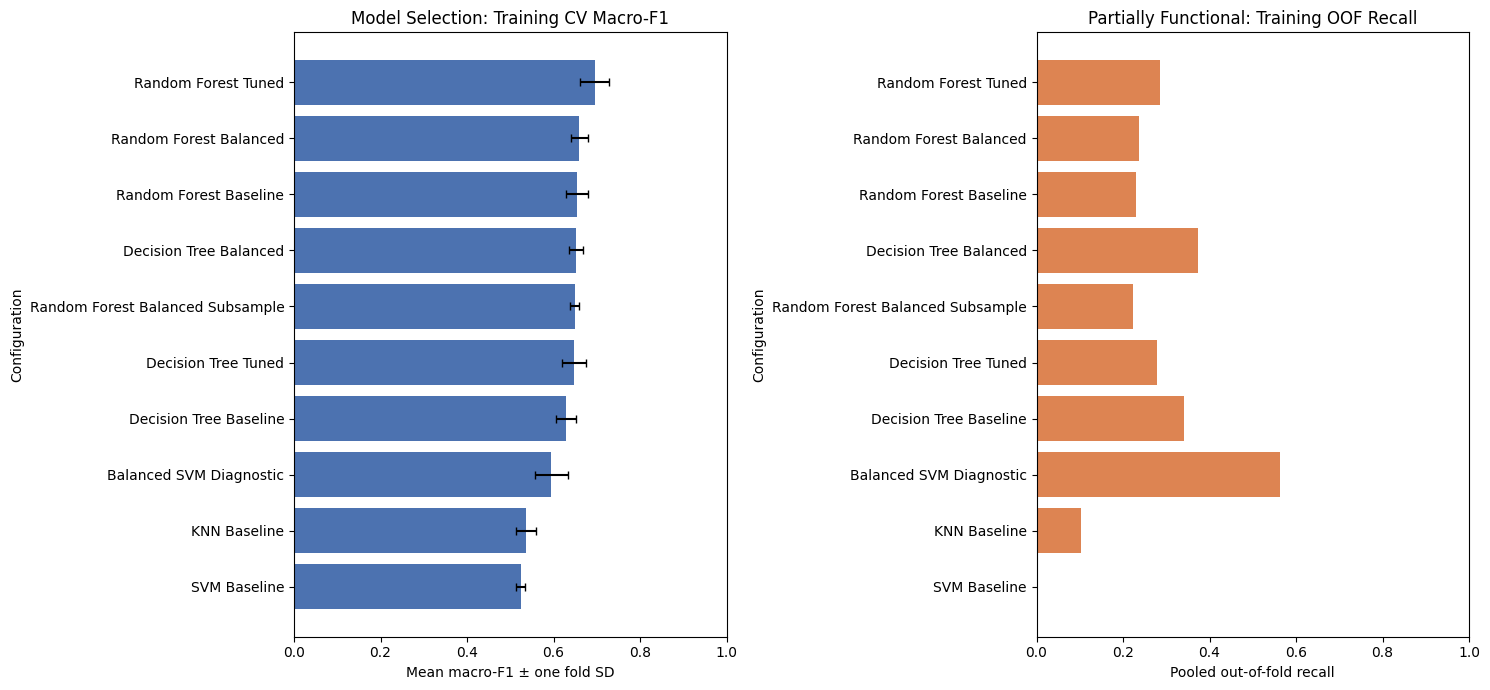

In [50]:
plot_data = comparison.sort_values("Mean CV Macro F1")
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
axes[0].barh(plot_data.index, plot_data["Mean CV Macro F1"], xerr=plot_data["Std CV Macro F1"], color="#4C72B0", capsize=3)
axes[0].set_title("Model Selection: Training CV Macro-F1")
axes[0].set_xlabel("Mean macro-F1 ± one fold SD")
axes[0].set_ylabel("Configuration")
axes[1].barh(plot_data.index, plot_data["Partially functional recall"], color="#DD8452")
axes[1].set_title("Partially Functional: Training OOF Recall")
axes[1].set_xlabel("Pooled out-of-fold recall")
axes[1].set_ylabel("Configuration")
for ax in axes:
    ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()


In [51]:
best_minority = comparison["Partially functional recall"].idxmax()
display(Markdown(f"**Observation:** **{best_minority}** has the highest minority recall "
    f"({comparison.loc[best_minority, 'Partially functional recall']:.4f}). "
    f"The macro-F1 leader is **{comparison.index[0]}**. "
    "The selection below considers both, while keeping macro-F1 as the primary criterion."))


**Observation:** **Balanced SVM Diagnostic** has the highest minority recall (0.5635). The macro-F1 leader is **Random Forest Tuned**. The selection below considers both, while keeping macro-F1 as the primary criterion.

# 13. Final Model Selection and Decision Lock

We select the configuration with the highest mean CV macro-F1. If scores are exactly equal at their available precision, minority recall then lower fold SD break the tie. We also show the runner-up and its score difference, so a small numerical lead is not presented as decisive evidence.

This is final selection for the current bounded experiment, not a claim that the search found a globally optimal model. The selected algorithm, full estimator parameters and class weighting are locked **before any holdout performance is computed**. No feature or tuning decision follows the final test.

In [52]:
assert holdout_evaluation_count == 0
selection_order = comparison.sort_values(
    ["Mean CV Macro F1", "Partially functional recall", "Std CV Macro F1"],
    ascending=[False, False, True],
)
selected_name = selection_order.index[0]
selected_estimator = clone(candidates[selected_name])
final_model_config = {"configuration": selected_name,
                      "algorithm": type(selected_estimator).__name__,
                      "parameters": selected_estimator.get_params(deep=False)}
selection_fingerprint = hashlib.sha256(json.dumps(final_model_config, sort_keys=True, default=str).encode()).hexdigest()
final_pipeline = model_pipeline(selected_estimator)
selected_cv_macro_f1 = float(comparison.loc[selected_name, "Mean CV Macro F1"])
runner_up = selection_order.index[1]
cv_lead = selected_cv_macro_f1 - float(comparison.loc[runner_up, "Mean CV Macro F1"])
display(pd.Series(final_model_config["parameters"], name="Final parameter value").to_frame())
print("Selected configuration:", selected_name)
print("Selected algorithm:", final_model_config["algorithm"])
print("Class-weight strategy:", final_model_config["parameters"].get("class_weight"))
print("Selection fingerprint:", selection_fingerprint)
print("Final model configuration selected using training cross-validation only. The test set has not yet been evaluated.")
display(Markdown(
    f"**Decision:** Select **{selected_name}**, with mean CV macro-F1 {selected_cv_macro_f1:.4f}, "
    f"fold SD {comparison.loc[selected_name, 'Std CV Macro F1']:.4f}, "
    f"minority recall {comparison.loc[selected_name, 'Partially functional recall']:.4f} and "
    f"minority F1 {comparison.loc[selected_name, 'Partially functional F1']:.4f}. "
    f"Its macro-F1 lead over **{runner_up}** is {cv_lead:.4f}. "
    + ("This lead is smaller than at least one of their fold SDs, so the ranking should not be treated as statistically decisive. "
       if cv_lead < max(comparison.loc[selected_name, 'Std CV Macro F1'], comparison.loc[runner_up, 'Std CV Macro F1']) else
       "The observed lead is larger than either individual fold SD, but this still does not establish statistical significance. ")
    + "The primary macro-F1 rule determines the selection; class-level trade-offs remain documented."
))


,Final parameter value
bootstrap,True
ccp_alpha,0.0
class_weight,None
criterion,gini
max_depth,20
max_features,0.5
max_leaf_nodes,None
max_samples,None
min_impurity_decrease,0.0
min_samples_leaf,1


Selected configuration: Random Forest Tuned
Selected algorithm: RandomForestClassifier
Class-weight strategy: None
Selection fingerprint: f988b595cb3600a4a43b3870abd0fdcc0d48f8eee30f7ac5724a3fbcefe36132
Final model configuration selected using training cross-validation only. The test set has not yet been evaluated.


**Decision:** Select **Random Forest Tuned**, with mean CV macro-F1 0.6950, fold SD 0.0342, minority recall 0.2857 and minority F1 0.3850. Its macro-F1 lead over **Random Forest Balanced** is 0.0359. The observed lead is larger than either individual fold SD, but this still does not establish statistical significance. The primary macro-F1 rule determines the selection; class-level trade-offs remain documented.

# 14. One-Time Final Holdout Evaluation

The decision is now fixed. We fit a fresh complete pipeline on all training rows, then call `predict(X_test)` **once** for the selected configuration. All final metrics, class reports and the confusion matrix reuse that single prediction array. The guard prevents a second holdout evaluation in the same session; restarting and rerunning reproduces the experiment but does not authorize tuning based on its result.

These are **FINAL HOLDOUT TEST RESULTS**, distinct from the training-CV selection table. We do not evaluate the other candidates on the holdout.

FINAL HOLDOUT TEST RESULTS — Random Forest Tuned


,FINAL HOLDOUT TEST RESULTS
Accuracy,0.8607
Macro Precision,0.7640
Macro Recall,0.6431
Macro F1,0.6811
Weighted F1,0.8452


,precision,recall,f1-score,support
Functional,0.8776,0.9663,0.9198,267.0
Partially functional,0.5714,0.2581,0.3556,31.0
Abandoned or not functional,0.8431,0.7049,0.7679,61.0
macro avg,0.7640,0.6431,0.6811,359.0
weighted avg,0.8453,0.8607,0.8452,359.0


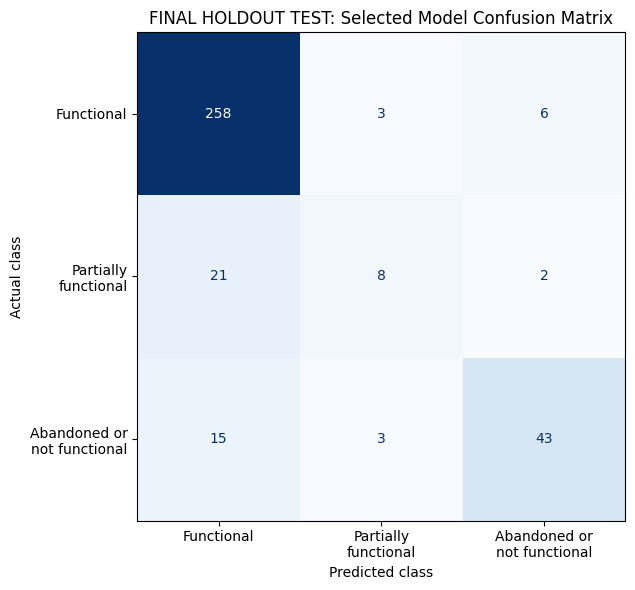

In [53]:
assert holdout_evaluation_count == 0, "Final holdout predictions have already been generated."
assert selection_fingerprint == hashlib.sha256(json.dumps(final_model_config, sort_keys=True, default=str).encode()).hexdigest()
final_pipeline.fit(X_development, y_development)
final_test_predictions = final_pipeline.predict(X_test)
holdout_evaluation_count += 1
assert holdout_evaluation_count == 1
final_test_metrics = pd.Series({
    "Accuracy": accuracy_score(y_test, final_test_predictions),
    "Macro Precision": precision_score(y_test, final_test_predictions, average="macro", zero_division=0),
    "Macro Recall": recall_score(y_test, final_test_predictions, average="macro", zero_division=0),
    "Macro F1": f1_score(y_test, final_test_predictions, average="macro", zero_division=0),
    "Weighted F1": f1_score(y_test, final_test_predictions, average="weighted", zero_division=0),
}, name="FINAL HOLDOUT TEST RESULTS")
final_test_report = classification_report(y_test, final_test_predictions, labels=CLASS_ORDER,
                                           output_dict=True, zero_division=0)
final_test_report_df = pd.DataFrame({label: final_test_report[label]
                                   for label in CLASS_ORDER + ["macro avg", "weighted avg"]}).T
print("FINAL HOLDOUT TEST RESULTS —", selected_name)
display(final_test_metrics.round(4).to_frame())
display(final_test_report_df.round(4))
final_confusion = confusion_matrix(y_test, final_test_predictions, labels=CLASS_ORDER)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(final_confusion, display_labels=["Functional", "Partially\nfunctional", "Abandoned or\nnot functional"]).plot(
    ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("FINAL HOLDOUT TEST: Selected Model Confusion Matrix")
ax.set_xlabel("Predicted class")
ax.set_ylabel("Actual class")
plt.tight_layout()
plt.show()


In [54]:
holdout_notes = []
for idx, label in enumerate(CLASS_ORDER):
    row = final_test_report[label]
    other_indices = [j for j in range(len(CLASS_ORDER)) if j != idx]
    largest_error = max(other_indices, key=lambda j: final_confusion[idx, j])
    holdout_notes.append(
        f"- **{label}:** precision {row['precision']:.4f}, recall {row['recall']:.4f}, "
        f"F1 {row['f1-score']:.4f}, support {int(row['support'])}. "
        f"The largest off-diagonal count is {final_confusion[idx, largest_error]} predicted as {CLASS_ORDER[largest_error]}."
    )
display(Markdown("**Observation:**\n\n" + "\n".join(holdout_notes)))


**Observation:**

- **Functional:** precision 0.8776, recall 0.9663, F1 0.9198, support 267. The largest off-diagonal count is 6 predicted as Abandoned or not functional.
- **Partially functional:** precision 0.5714, recall 0.2581, F1 0.3556, support 31. The largest off-diagonal count is 21 predicted as Functional.
- **Abandoned or not functional:** precision 0.8431, recall 0.7049, F1 0.7679, support 61. The largest off-diagonal count is 15 predicted as Functional.

# 15. Compare Training CV and Final Test Performance

We compare the selected configuration's CV estimate with its one-time final test estimate. The holdout is smaller, particularly for the rare class, so class-level estimates can vary substantially. Repeated search on training CV can also make the winning CV score optimistic. Neither a higher nor lower test score changes the locked decision.

In [55]:
cv_test_comparison = pd.DataFrame({
    "Selected training CV": [selected_cv_macro_f1, comparison.loc[selected_name, "Partially functional recall"],
                             comparison.loc[selected_name, "Partially functional F1"]],
    "Final holdout": [final_test_metrics["Macro F1"], final_test_report["Partially functional"]["recall"],
                      final_test_report["Partially functional"]["f1-score"]],
}, index=["Macro-F1 (CV fold mean / holdout)", "Partially functional recall (OOF / holdout)", "Partially functional F1 (OOF / holdout)"])
display(cv_test_comparison.round(4))
test_cv_delta = final_test_metrics["Macro F1"] - selected_cv_macro_f1
display(Markdown(
    f"**Observation:** Holdout macro-F1 is {final_test_metrics['Macro F1']:.4f}, "
    f"compared with selected CV macro-F1 {selected_cv_macro_f1:.4f} (change {test_cv_delta:+.4f}). "
    + ("The lower holdout score indicates weaker measured generalization on this reserved sample; "
       "CV selection optimism and sampling differences are possible explanations, not proven causes. " if test_cv_delta < 0 else
       "The holdout score is at least as high on this sample; this does not establish performance on every future dataset. ")
    + f"The holdout contains {int(final_test_report['Partially functional']['support'])} Partially functional cases. "
    "The selected configuration is unchanged and no further tuning is performed."
))


,Selected training CV,Final holdout
Macro-F1 (CV fold mean / holdout),0.6950,0.6811
Partially functional recall (OOF / holdout),0.2857,0.2581
Partially functional F1 (OOF / holdout),0.3850,0.3556


**Observation:** Holdout macro-F1 is 0.6811, compared with selected CV macro-F1 0.6950 (change -0.0140). The lower holdout score indicates weaker measured generalization on this reserved sample; CV selection optimism and sampling differences are possible explanations, not proven causes. The holdout contains 31 Partially functional cases. The selected configuration is unchanged and no further tuning is performed.

# 16. Serialization and Integration Status

The selected pipeline is fitted in memory. Its custom preprocessing class and functions still live in notebook scope, so saving a joblib object here would create a fragile artifact requiring those notebook-local definitions at load time. We do not force serialization or generate model-serving files.

**Final model selected and fitted; deployment-safe serialization remains a separate implementation step.** A reusable importable preprocessing module and a consistent scikit-learn environment must be established before export and backend integration. Any saved-artifact version mismatch reported earlier remains an integration issue.

# 17. Final Optimization Summary

The summary is generated from executed results. We verify that the selection remains locked, that only one holdout prediction pass occurred, and that all existing source/artifact hashes are unchanged. Search size, class-level results, remaining artifact issues and export status are recorded without inventing missing files.

In [56]:
assert holdout_evaluation_count == 1
assert selection_fingerprint == hashlib.sha256(json.dumps(final_model_config, sort_keys=True, default=str).encode()).hexdigest()
assert all(file_hash(path) == original for path, original in protected_hashes.items()), "An existing project file changed."
print("STAGE 7 — MODEL OPTIMIZATION AND FINAL SELECTION SUMMARY")
print("Training raw predictors:", X_train.shape, "| Holdout raw predictors:", X_test.shape)
print("Reference processed training:", training_reference.shape)
print("Validation: 5-fold StratifiedKFold, shuffle=True, random_state=42; fold-safe preprocessing")
print("Primary metric: macro-F1")
print("Search budget: Random Forest 24 candidates; Decision Tree 32 candidates")
print("Search times (s): RF", round(rf_elapsed, 2), "| DT", round(dt_elapsed, 2))
print("SMOTE: not used.", resampling_reason)
display(comparison.round(4))
print("Final selected configuration:", selected_name)
print("Final selected parameters:", final_model_config["parameters"])
print("Selected training CV macro-F1:", round(selected_cv_macro_f1, 4))
print("Final holdout performance:")
display(final_test_metrics.round(4).to_frame())
display(final_test_report_df.round(4))
print("y_test used for tuning/model selection: NO")
print("Final selected configuration evaluated on holdout: one prediction pass; no subsequent tuning")
print("Optional audit files present:", ", ".join(existing_artifacts) or "None")
print("Optional audit files missing:", ", ".join(missing_artifacts) or "None")
print("Saved pipeline verification:", pipeline_verification)
print("Runtime sklearn:", sklearn.__version__)
print("requirements.txt:", "Read; unchanged" if requirements_text is not None else "Absent; project version constraint not verified")
print("Existing project source/artifact hashes: PASS")
print("Final model selected and fitted; deployment-safe serialization remains a separate implementation step.")
print("Only notebook 05 is produced. No model export, backend or frontend files are created.")


STAGE 7 — MODEL OPTIMIZATION AND FINAL SELECTION SUMMARY
Training raw predictors: (1434, 32) | Holdout raw predictors: (359, 32)
Reference processed training: (1434, 110)
Validation: 5-fold StratifiedKFold, shuffle=True, random_state=42; fold-safe preprocessing
Primary metric: macro-F1
Search budget: Random Forest 24 candidates; Decision Tree 32 candidates
Search times (s): RF 203.58 | DT 39.7
SMOTE: not used. Weighting improved minority recall without reducing macro-F1 for Decision Tree Balanced, Random Forest Balanced, Balanced SVM Diagnostic. SMOTE was therefore not applied in this optimization stage. Given the remaining low recall for the Partially functional class, leakage-safe resampling remains a possible future experiment.


,Mean CV Accuracy,Mean CV Macro Precision,Mean CV Macro Recall,Mean CV Macro F1,Std CV Macro F1,Mean CV Weighted F1,Mean Fit Time (s),Partially functional precision,Partially functional recall,Partially functional F1
Configuration,,,,,,,,,,
Random Forest Tuned,0.8619,0.7605,0.6674,0.6950,0.0342,0.8493,4.8749,0.5902,0.2857,0.3850
Random Forest Balanced,0.8459,0.7577,0.6217,0.6592,0.0197,0.8285,0.3882,0.6000,0.2381,0.3409
Random Forest Baseline,0.8459,0.7308,0.6247,0.6542,0.0254,0.8293,0.3752,0.5370,0.2302,0.3222
Decision Tree Balanced,0.8047,0.6485,0.6590,0.6518,0.0156,0.8079,0.0958,0.3357,0.3730,0.3534
Random Forest Balanced Subsample,0.8424,0.7466,0.6134,0.6488,0.0099,0.8239,0.4623,0.5833,0.2222,0.3218
Decision Tree Tuned,0.8236,0.6705,0.6405,0.6474,0.0277,0.8157,0.1401,0.4375,0.2778,0.3398
Decision Tree Baseline,0.7950,0.6276,0.6324,0.6289,0.0224,0.7983,0.1121,0.2966,0.3413,0.3173
Balanced SVM Diagnostic,0.6946,0.5977,0.6675,0.5947,0.0378,0.7398,0.1678,0.1919,0.5635,0.2863
KNN Baseline,0.7950,0.6424,0.5190,0.5365,0.0226,0.7670,0.0737,0.3824,0.1032,0.1625


Final selected configuration: Random Forest Tuned
Final selected parameters: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 20, 'max_features': 0.5, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 500, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
Selected training CV macro-F1: 0.695
Final holdout performance:


,FINAL HOLDOUT TEST RESULTS
Accuracy,0.8607
Macro Precision,0.7640
Macro Recall,0.6431
Macro F1,0.6811
Weighted F1,0.8452


,precision,recall,f1-score,support
Functional,0.8776,0.9663,0.9198,267.0
Partially functional,0.5714,0.2581,0.3556,31.0
Abandoned or not functional,0.8431,0.7049,0.7679,61.0
macro avg,0.7640,0.6431,0.6811,359.0
weighted avg,0.8453,0.8607,0.8452,359.0


y_test used for tuning/model selection: NO
Final selected configuration evaluated on holdout: one prediction pass; no subsequent tuning
Optional audit files present: X_train_processed.csv, X_test_processed.csv, y_train.csv, y_test.csv, feature_names.csv, preprocessing_pipeline.joblib, preprocessing_decisions.md
Optional audit files missing: None
Saved pipeline verification: Skipped saved-pipeline verification: artifact sklearn version 1.9.1 differs from runtime 1.8.0. Use one compatible sklearn version across notebook 03, modelling, optimization and eventual backend use. CV continues with the exact reconstructed preprocessing; no artifact was regenerated.
Runtime sklearn: 1.8.0
requirements.txt: Read; unchanged
Existing project source/artifact hashes: PASS
Final model selected and fitted; deployment-safe serialization remains a separate implementation step.
Only notebook 05 is produced. No model export, backend or frontend files are created.


**Observation:** The notebook completes the class-weight investigation, bounded tuning, training-only final selection and one-time holdout evaluation. Class-level findings and the CV–test comparison remain visible above. Existing preprocessing decisions and artifacts are preserved.

**Model optimization and final selection complete. STOPPING HERE. Robust export, backend integration, frontend development and deployment are separate implementation steps.**